In [1]:
import shap
import joblib
from scipy import sparse

In [2]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[-().,:;?!]", " ", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [3]:
model = joblib.load('..\\models\\model.joblib')
X_train_features = sparse.load_npz('..\\data\\features\\X_train_features.npz')
X_test_features = sparse.load_npz('..\\data\\features\\X_test_features.npz')

In [4]:
X_test_features

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 6988580 stored elements and shape (25000, 436739)>

In [6]:
clf = model['lr']

explainer = shap.LinearExplainer(clf, X_train_features, shap.maskers.Independent)
shap_values = explainer(X_test_features[:100])

.values =
array([[-0., -0., -0., ...,  0., -0., -0.],
       [-0., -0., -0., ...,  0., -0., -0.],
       [-0., -0., -0., ...,  0., -0., -0.],
       ...,
       [-0., -0., -0., ...,  0., -0., -0.],
       [-0., -0., -0., ...,  0., -0., -0.],
       [-0., -0., -0., ...,  0., -0., -0.]], shape=(100, 436739))

.base_values =
array([-0.15793855, -0.15793855, -0.15793855, -0.15793855, -0.15793855,
       -0.15793855, -0.15793855, -0.15793855, -0.15793855, -0.15793855,
       -0.15793855, -0.15793855, -0.15793855, -0.15793855, -0.15793855,
       -0.15793855, -0.15793855, -0.15793855, -0.15793855, -0.15793855,
       -0.15793855, -0.15793855, -0.15793855, -0.15793855, -0.15793855,
       -0.15793855, -0.15793855, -0.15793855, -0.15793855, -0.15793855,
       -0.15793855, -0.15793855, -0.15793855, -0.15793855, -0.15793855,
       -0.15793855, -0.15793855, -0.15793855, -0.15793855, -0.15793855,
       -0.15793855, -0.15793855, -0.15793855, -0.15793855, -0.15793855,
       -0.15793855, -0.15793

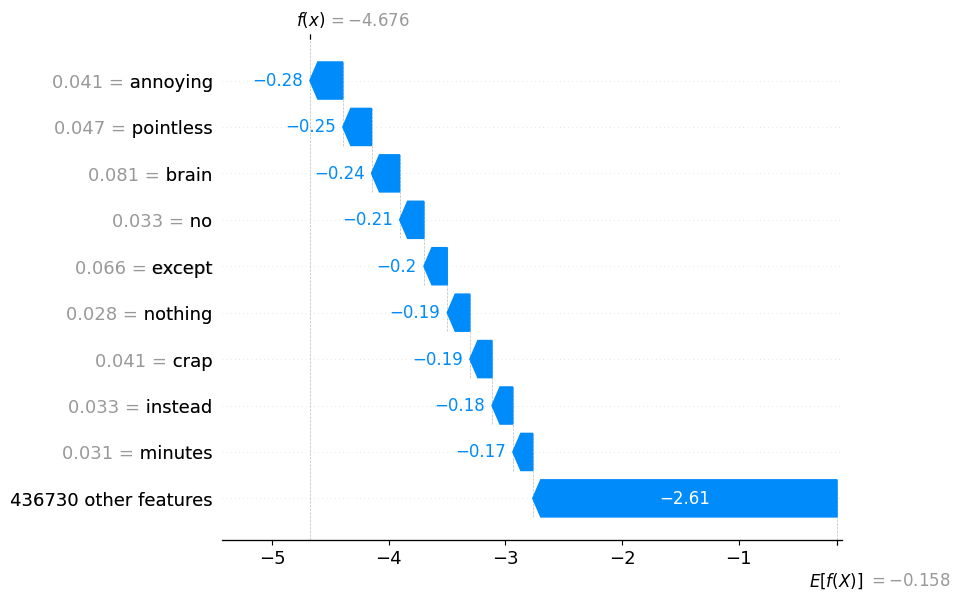

In [16]:
tfidf = model['tfidf']

i = 2
print(shap_values)
feature_names = tfidf.get_feature_names_out()

shap_exp = shap.Explanation(
    values=shap_values[i],
    base_values=explainer.expected_value,
    data=X_test_features[i],
    feature_names=feature_names
)

shap.plots.waterfall(shap_exp)

In [15]:
y_pred = clf.predict(X_test_features[i])
y_pred

array([0])